In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.interpolate import interp1d
from scipy.optimize import brentq

plt.rcParams.update({
    "font.size": 14,                 # 全局字号
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.direction": "in",         # 刻度朝内
    "ytick.direction": "in",
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.figsize": (5, 4),        # 图片默认大小
})

In [2]:
df = pd.read_csv("summary_all.csv")
df = df[df['T']<0.21]

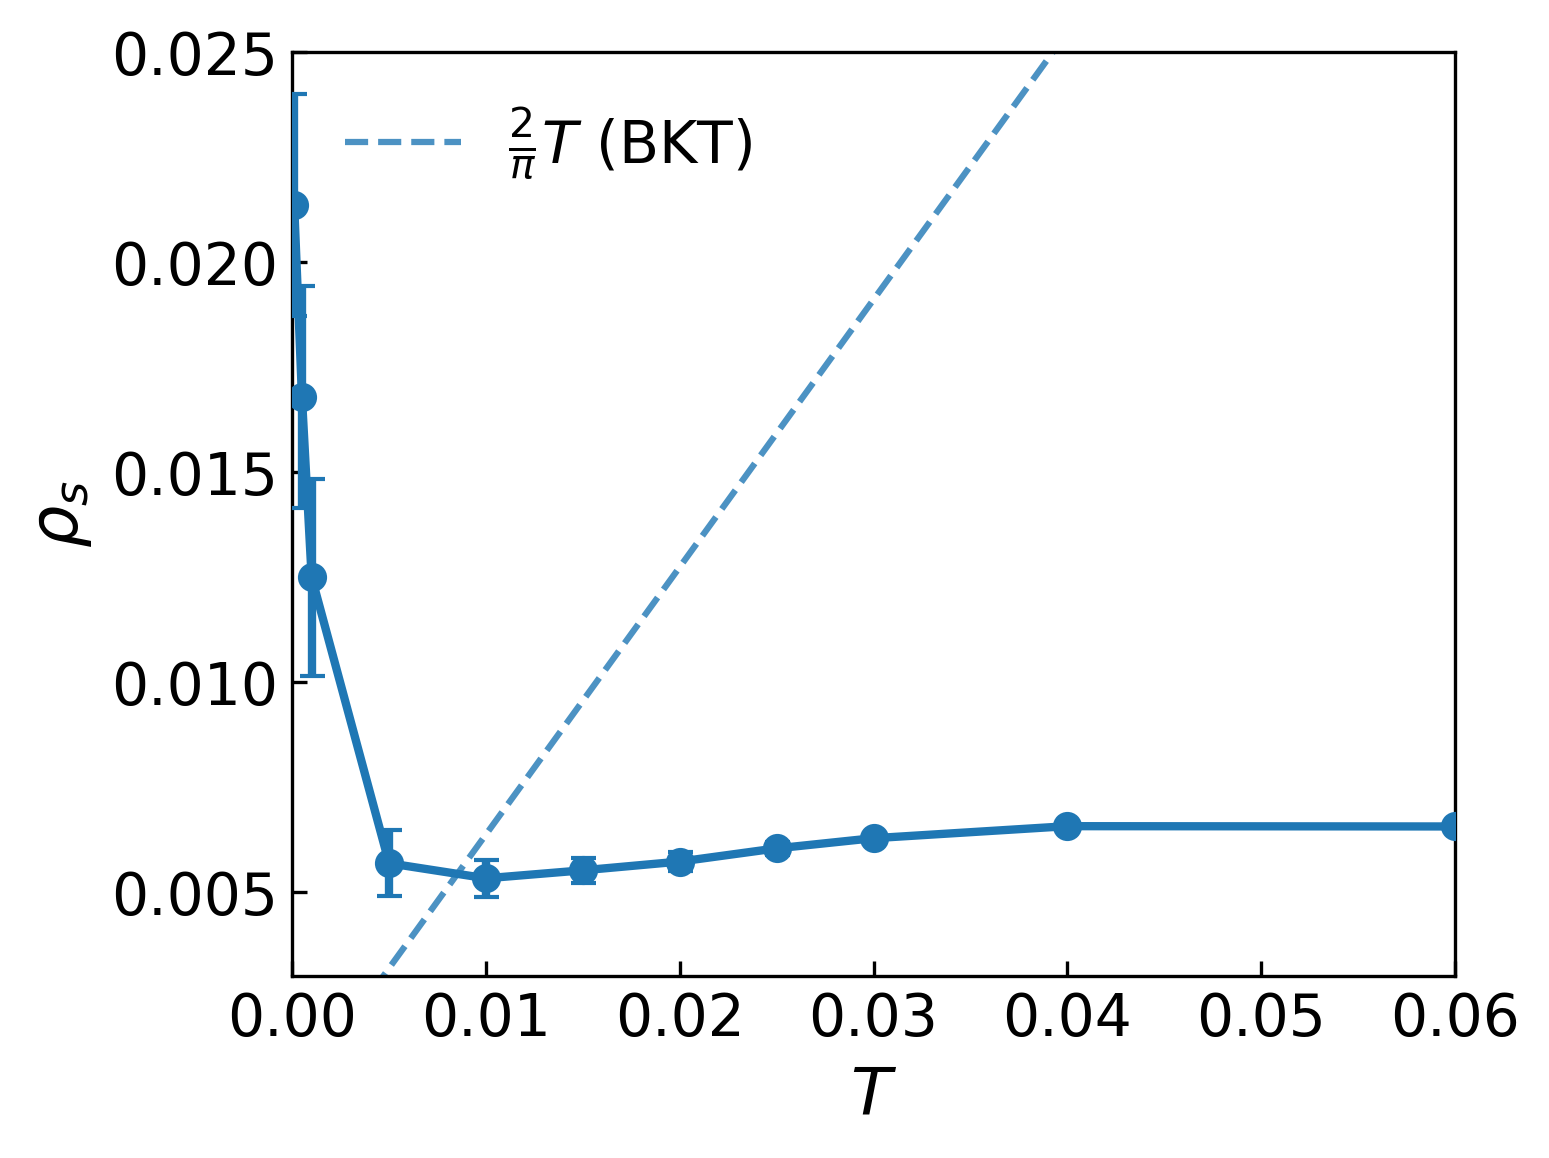

In [20]:
fig, ax = plt.subplots(dpi=300)

ax.errorbar(df['T'], df['Superfluid_Stiffness_mean'], yerr=df['Superfluid_Stiffness_err'], 
            fmt='-o', capsize=3, color='tab:blue', zorder=3)
# ax.errorbar(df['T'], df['B_local_mean'], yerr=df['B_local_err'],
#             fmt='-o', capsize=3, label=r'$B_{\mathrm{local}}$', color='tab:purple', zorder=3)

# 绘制 BKT 判据线: rho = 2/pi * T
t_min = df['T'].min()
t_max = df['T'].max()
T_line = np.logspace(np.log10(t_min), np.log10(t_max), 200)
rho_BKT = (2.0 / np.pi) * T_line
ax.plot(T_line, rho_BKT, linestyle='--', color='tab:blue', linewidth=1.5, alpha=0.8,
        label=r'$\frac{2}{\pi}T$ (BKT)', zorder=2)

# 计算并标记 BKT 转变温度 Tc
diff_func = interp1d(df['T'], df['Superfluid_Stiffness_mean'] - (2/np.pi)*df['T'], kind='linear')
Tc = brentq(diff_func, df['T'].min(), df['T'].max())
# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c={Tc:.3f}$')

# temp
# ax.axvline(x=0.005, color='black', linestyle='-', linewidth=1.5)

# 设置坐标轴
ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$\rho_s$')
ax.set_ylim(0.003,0.025) 
ax.set_xlim(0,0.06) 

ax.legend(loc='best', frameon=False)
plt.show()

In [4]:
# fig, ax = plt.subplots(dpi=300)

# ax.errorbar(df['T'], df['Delta_Pair_mean'], yerr=df['Delta_Pair_err'], 
#             fmt='-o', capsize=3, label=r'$|\Delta|_\mathrm{global}$', color='tab:orange', zorder=3)
# ax.errorbar(df['T'], df['Delta_LocalPair_mean'], yerr=df['Delta_LocalPair_err'], 
#             fmt='-o', capsize=3, label=r'$|\Delta|_\mathrm{local}$', color='tab:purple', zorder=3)

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# # 设置坐标轴
# ax.set_xlabel(r'$T$')
# ax.set_ylabel(r'$\Delta$')
# # ax.set_ylim(-0.002,0.08) 
# ax.set_xlim(0,0.08) 

# ax.legend(loc='best', frameon=False)
# plt.show()

In [5]:
# fig, ax = plt.subplots(dpi=300)

# ax.errorbar(df['T'], df['Delta_Loc_mean'], yerr=df['Delta_Loc_err'], 
#             fmt='-o', capsize=3, label=r'$|\Delta|_\mathrm{local-field}$', color='tab:red', zorder=3)
# ax.errorbar(df['T'], df['Delta_LocalPair_mean'], yerr=df['Delta_LocalPair_err'], 
#             fmt='-o', capsize=3, label=r'$|\Delta|_\mathrm{local}$', color='tab:purple', zorder=3)
# ax.errorbar(df['T'], df['Delta_LocalPair_mean']/df['Delta_Loc_mean'], yerr=df['Delta_LocalPair_err']/df['Delta_Loc_mean'], 
#             fmt='-o', capsize=3, label=r'$\chi_\mathrm{local}$', color='tab:blue', zorder=3)

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# # 设置坐标轴
# ax.set_xlabel(r'$T$')
# ax.set_ylabel(r'$\Delta$')
# ax.set_ylim(-0.002,1) 
# ax.set_xlim(0,0.08) 

# ax.legend(loc='best', frameon=False)
# plt.show()

In [6]:
# fig, ax = plt.subplots(dpi=300)

# T = df['T'][df['T']>Tc]
# sigma = df['DC_Conductivity_mean'][df['T']>Tc]
# sigma_err = df['DC_Conductivity_err'][df['T']>Tc]

# R = 1 / sigma
# R_err = sigma_err / (sigma**2)

# ax.errorbar(T, R, yerr=R_err, 
#             fmt='-o', capsize=3, color='tab:green', zorder=3)

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# # temp
# # ax.axvline(x=0.08, color='black', linestyle='-', linewidth=1.5)

# # 设置坐标轴
# ax.set_xlabel(r'$T$')
# ax.set_ylabel(r'$R$')
# # ax.set_ylim(0.49,0.81) 
# ax.set_xlim(0,0.2) 

# ax.legend(loc='best', frameon=False)
# plt.show()

In [7]:
# fig, ax = plt.subplots(dpi=300)

# T = df['T'][:]
# p = df['Hole_p_mean'][:]
# p_err = df['Hole_p_err'][:]


# ax.errorbar(T, p, yerr=p_err, 
#             fmt='-o', capsize=3, color='tab:red', zorder=3)

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# # 设置坐标轴
# ax.set_xlabel(r'$T$')
# ax.set_ylabel(r'$p$')
# # ax.set_ylim(0.241,0.264) 
# ax.set_xlim(0,0.08) 

# ax.legend(loc='best', frameon=False)
# plt.show()

In [8]:
# fig, ax = plt.subplots(dpi=300)

# T = df['T'][df['T']>Tc]
# sigma = df['DC_Conductivity_mean'][df['T']>Tc]
# sigma_err = df['DC_Conductivity_err'][df['T']>Tc]
# p = df['Hole_p_mean'][df['T']>Tc]
# p_err = df['Hole_p_err'][df['T']>Tc]

# Rmp = 1 / sigma * p
# Rmp_err = sigma_err / (sigma**2) * p + p_err / sigma

# ax.errorbar(T, Rmp, yerr=Rmp_err, 
#             fmt='-o', capsize=3, color='tab:green', zorder=3)

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# # 设置坐标轴
# ax.set_xlabel(r'$T$')
# ax.set_ylabel(r'$Rp$')
# # ax.set_ylim(0.19,0.61) 
# # ax.set_xlim(0,0.1) 

# ax.legend(loc='best', frameon=False)
# plt.show()

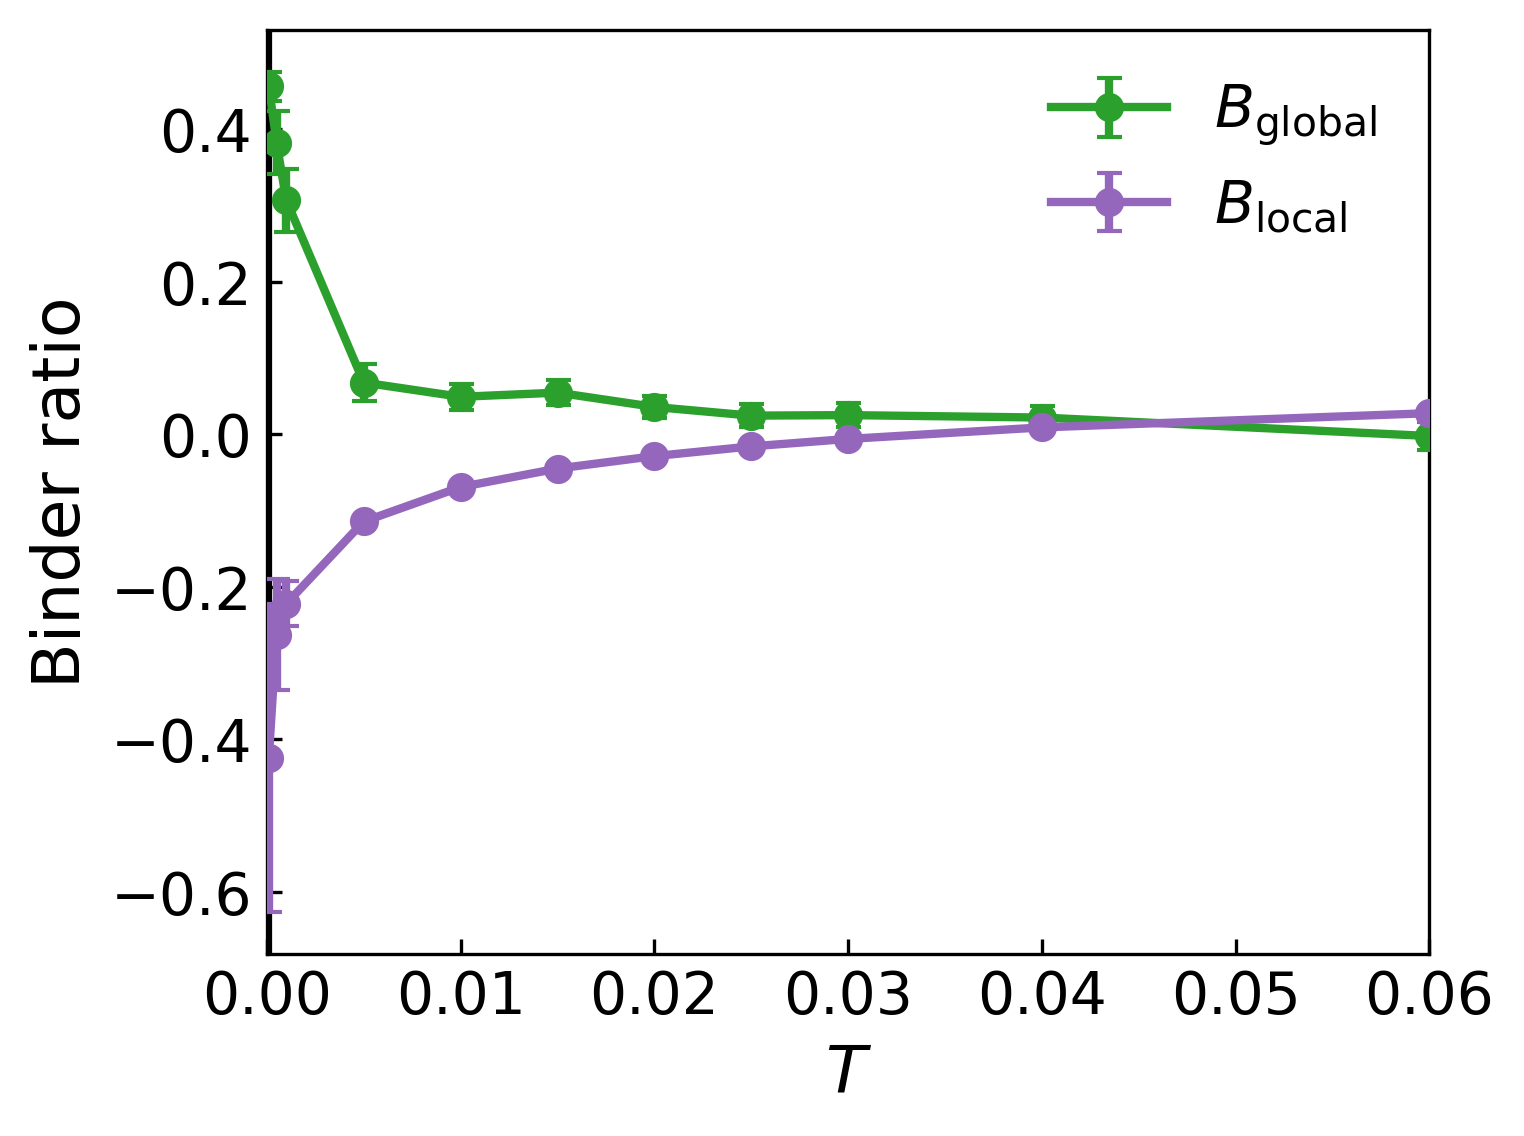

In [9]:
fig, ax = plt.subplots(dpi=300)

ax.errorbar(df['T'], df['B_global_mean'], yerr=df['B_global_err'],
            fmt='-o', capsize=3, label=r'$B_{\mathrm{global}}$', color='tab:green', zorder=3)
ax.errorbar(df['T'], df['B_local_mean'], yerr=df['B_local_err'],
            fmt='-o', capsize=3, label=r'$B_{\mathrm{local}}$', color='tab:purple', zorder=3)

# if 'Tc' in globals():
#     ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# temp
ax.axvline(x=0.0001, color='black', linestyle='-', linewidth=1.5)

ax.set_xlabel(r'$T$')
ax.set_ylabel(r'Binder ratio')
# ax.set_ylim(-0.05, 0.55)
ax.set_xlim(0, 0.06)

ax.legend(loc='best', frameon=False)
plt.show()


In [ ]:
# Phase-correlation observable (default: S_L2_0)
fig, ax = plt.subplots(dpi=300)

ax.errorbar(df['T'], df['S_L2_0_mean'], yerr=df['S_L2_0_err'],
            fmt='-o', capsize=3, label=r'$S(L/2,0)$', color='tab:blue', zorder=3)

# Optional overlays:
# ax.errorbar(df['T'], df['S_1_0_mean'], yerr=df['S_1_0_err'],
#             fmt='-o', capsize=3, label=r'$S(1,0)$', color='tab:orange', zorder=3)
# ax.errorbar(df['T'], df['S_L2_L2_mean'], yerr=df['S_L2_L2_err'],
#             fmt='-o', capsize=3, label=r'$S(L/2,L/2)$', color='tab:green', zorder=3)
# ax.errorbar(df['T'], df['F_0_0_mean'], yerr=df['F_0_0_err'],
#             fmt='-o', capsize=3, label=r'$F(0,0)$', color='tab:red', zorder=3)

ax.set_xlabel(r'$T$')
ax.set_ylabel('Phase Correlation')
ax.set_xlim(0, 0.08)
ax.legend(loc='best', frameon=False)
plt.show()
